# Pré-processamento
## Parte 3: Filtragem dos Sinais

### O que esta parte faz

Na Parte 2 todos os sinais chegaram a 500Hz e alinhados no tempo.
Mas eles ainda estão **brutos** — contêm ruídos que não são sinal fisiológico real.

**Filtrar é remover os ruídos sem destruir o sinal.**

Cada tipo de sinal tem seu ruído característico:

| Sinal | Ruído principal | Filtro |
|-------|----------------|--------|
| EEG   | Rede elétrica (50Hz), artefato muscular (>40Hz), deriva DC (<1Hz) | Passa-banda 1–40Hz + Notch 50Hz |
| EMG   | Componente DC, ruído eletrônico acima do sinal muscular | Passa-banda 20–249Hz |
| ECG   | Deriva da linha de base por respiração (<0.5Hz) | Passa-banda 0.5–40Hz |
| IO    | Ruído de alta frequência acima do movimento ocular | Passa-baixa 10Hz |
| IMU   | Vibração mecânica do suporte do sensor (>20Hz) | Passa-baixa 20Hz |

### Por que filtrar por paciente × tarefa e não no dataset inteiro?

> Filtrar na concatenação inteira criaria **artefatos de borda** entre pacientes.
> O filtro digital não sabe onde um paciente termina e o outro começa —
> ele tentaria suavizar a transição entre o último ponto do paciente 001
> e o primeiro do 002, que são completamente não relacionados.
> É como tentar suavizar a costura entre duas músicas diferentes:
> o resultado soa estranho nas bordas.

---
### Entrada
- `data/silver/resampled.parquet` — saída da Parte 2 (500Hz, sinais brutos)

### Saída
- `data/silver/filtered.parquet` — mesmos sinais com ruído removido
---

## 0. Carregar definições e dado resampleado

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal as sg

# ── Caminhos ──────────────────────────────────────────────────────────────────
ROOT           = Path("..")
RESAMPLED_PATH = ROOT / "data" / "silver" / "resampled.parquet"
FILTERED_PATH  = ROOT / "data" / "silver" / "filtered.parquet"

# ── Constantes ────────────────────────────────────────────────────────────────
FS      = 500              # frequência de amostragem do dado de entrada
NYQUIST = FS / 2           # = 250Hz — frequência máxima representável
# Qualquer filtro com corte acima de 250Hz não tem efeito neste dado

FREQ_REDE_HZ = 50.0
#  Brasil = 60Hz | Europa/China = 50Hz — ajuste se necessário

# ── Colunas ───────────────────────────────────────────────────────────────────
EEG_COLS = [
    'EEG-FP1','EEG-FP2','EEG-F3','EEG-F4','EEG-C3','EEG-C4',
    'EEG-P3','EEG-P4','EEG-O1','EEG-O2','EEG-F7','EEG-F8',
    'EEG-P7','EEG-P8','EEG-FZ','EEG-CZ','EEG-PZ',
    'EEG-FC1','EEG-FC2','EEG-CP1','EEG-CP2',
    'EEG-FC5','EEG-FC6','EEG-CP5','EEG-CP6'
]
EMG_COLS       = ['EMG-RTA', 'EMG-LTA', 'EMG-RGS']
BIO_COLS       = EMG_COLS + ['IO', 'ECG']
SENSOR_NAMES   = ['LShank', 'RShank', 'Waist', 'Arm']
IMU_SINAL_SUF  = ['ACCX','ACCY','ACCZ','GYRO-X','GYRO-Y','GYRO-Z']
IMU_COLS_SINAL = [f"{s}-{ax}" for s in SENSOR_NAMES for ax in IMU_SINAL_SUF]
# NC/SC não é sinal contínuo — não será filtrado

# ── Carregar dado ─────────────────────────────────────────────────────────────
print("Carregando resampled.parquet...")
df = pd.read_parquet(RESAMPLED_PATH)
print(f"Shape: {df.shape[0]:,} × {df.shape[1]}  "
      f"| Memória: {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
print("Definições carregadas.")

Carregando resampled.parquet...
Shape: 1,936,470 × 63  | Memória: 548.0 MB
Definições carregadas.


## 1.1 Construir os Filtros

Usamos filtros **Butterworth**: são a escolha padrão para biosinais
porque têm resposta em frequência maximamente plana na banda passante.

> **Analogia:** Um filtro Butterworth é como um porteiro muito educado:
> deixa entrar tudo que está dentro da lista (banda passante) sem
> incomodar, e barra suavemente quem está fora. Outros filtros
> (Chebyshev, Elliptic) são mais agressivos e criam 'repiques' no
> sinal, que indesejáveis quando queremos preservar a forma de onda.

Todos os filtros usam `sosfiltfilt` = filtra em frente **e** em trás.
Isso garante **fase zero**: o filtro não desloca o sinal no tempo,
o que é essencial para manter o alinhamento entre os canais.

## Escolha dos filtros e frequências de corte

Após o resample, todos os sinais passaram a ter frequência de amostragem de 500 Hz. Assim, a frequência máxima que pode ser representada corretamente é dada pelo limite de Nyquist:

$f_{Nyquist} = \frac{500}{2} = 250\text{ Hz}$

Isso significa que frequências acima de 250 Hz não podem ser representadas corretamente no sinal digital e podem gerar aliasing.

### EEG

Para os sinais de EEG, foi utilizado um filtro passa-banda entre 1 Hz e 40 Hz:

$1\text{ Hz} \leq f \leq 40\text{ Hz}$

A escolha desse intervalo é baseada nas bandas fisiológicas mais relevantes do EEG:

- Delta: aproximadamente 0.5–4 Hz
- Theta: aproximadamente 4–8 Hz
- Alpha: aproximadamente 8–13 Hz
- Beta: aproximadamente 13–30 Hz
- Parte da banda Gamma baixa: até cerca de 40 Hz

Frequências abaixo de 1 Hz geralmente correspondem a deriva de linha de base, suor, movimentação lenta dos eletrodos e artefatos de baixa frequência. Frequências acima de 40 Hz tendem a conter principalmente ruído muscular, interferência elétrica e artefatos de alta frequência.

### EMG

Para os sinais de EMG, foi utilizado um filtro passa-banda entre 20 Hz e 200 Hz:

$20\text{ Hz} \leq f \leq 200\text{ Hz}$

Os sinais de EMG possuem conteúdo útil em frequências mais altas que EEG. Valores abaixo de 20 Hz normalmente são associados a movimento, deriva de base e ruído de baixa frequência. O limite superior foi definido próximo ao limite de Nyquist (250 Hz), permitindo preservar a maior parte do conteúdo útil do EMG sem ultrapassar a frequência máxima representável.

### IMU

Para os sinais de IMU, foi utilizado um filtro passa-baixa de 20 Hz:

$f \leq 20\text{ Hz}$

Movimentos humanos típicos, como caminhar, sentar, levantar e mover membros, concentram a maior parte de sua energia abaixo de 20 Hz. Frequências acima disso costumam representar vibração do sensor, ruído eletrônico e pequenas oscilações sem relevância biomecânica.

### Filtro Notch em 50 Hz

Também foi aplicado um filtro notch em 50 Hz:

$f_{notch} = 50\text{ Hz}$

Esse filtro remove especificamente a interferência da rede elétrica, que no Brasil opera em 60 Hz e na China, onde o experimento foi feito, em 50 Hz. Esse ruído costuma aparecer em EEG, EMG e ECG como uma oscilação artificial constante sobreposta ao sinal.

### Por que usar -3 dB como frequência de corte?

Em filtros digitais, a frequência de corte normalmente é definida no ponto de -3 dB. Esse valor não é arbitrário: ele corresponde ao ponto em que a potência do sinal cai para metade do valor original.

$-3\text{ dB} \Rightarrow \text{potência reduzida à metade}$

Mais precisamente:

$20\log_{10}(0.707) \approx -3\text{ dB}$

Isso significa que, na frequência de corte, a amplitude do sinal cai para aproximadamente 70,7% do valor original. Esse ponto é usado internacionalmente como referência padrão para definir o início efetivo da atenuação de um filtro.

Portanto, quando se diz que um filtro possui corte em 40 Hz, isso significa que em 40 Hz o sinal já caiu aproximadamente 3 dB e, acima disso, a atenuação aumenta progressivamente.

### Por que observar -40 dB?

Em gráficos de resposta em frequência, -40 dB costuma ser usado como referência para indicar que determinada frequência foi fortemente atenuada.

$-40\text{ dB} \Rightarrow \text{forte atenuação do sinal}$

Uma atenuação de -40 dB corresponde aproximadamente a reduzir a amplitude para 1% do valor original. Na prática, isso significa que a frequência foi quase totalmente removida.

### Referências técnicas

Os intervalos escolhidos são consistentes com literatura clássica de processamento de biossinais:

- EEG: faixa de 1–40 Hz amplamente utilizada em estudos clínicos e de neuroengenharia.
- EMG: faixa de aproximadamente 20–250 Hz recomendada em processamento de eletromiografia.
- IMU: movimentos humanos geralmente abaixo de 20 Hz em estudos biomecânicos.
- Notch em 50 Hz: prática padrão em países cuja rede elétrica opera em 50 Hz.
- Frequência de corte em -3 dB: definição clássica em teoria de filtros e processamento de sinais.


In [18]:
def butter_passabanda(f_low: float, f_high: float, ordem: int = 4):
    """
    Cria um filtro passa-banda Butterworth.
    Deixa passar apenas frequências ENTRE f_low e f_high.

    Exemplo:
        butter_passabanda(1, 40)   → passa 1Hz até 40Hz  (EEG)
        butter_passabanda(20, 249) → passa 20Hz até 249Hz (EMG)

    ordem=4: equilíbrio entre nitidez do corte e estabilidade numérica.
    Ordens maiores cortam mais agressivamente mas podem instabilizar.

    Retorna coeficientes em formato SOS (Second-Order Sections) —
    mais estável numericamente do que o formato b,a clássico.
    """
    low  = f_low  / NYQUIST
    high = f_high / NYQUIST
    return sg.butter(ordem, [low, high], btype='band', output='sos')


def butter_passabaixa(f_corte: float, ordem: int = 4):
    """
    Cria um filtro passa-baixa Butterworth.
    Deixa passar apenas frequências ABAIXO de f_corte.

    Exemplo:
        butter_passabaixa(20) → passa 0 até 20Hz (movimento humano no IMU)

    Movimento humano real é lento (0–20Hz).
    O tremor de Parkinson está entre 3–7Hz — bem dentro da faixa.
    Acima de 20Hz no acelerômetro é vibração mecânica do sensor.
    """
    corte = f_corte / NYQUIST
    return sg.butter(ordem, corte, btype='low', output='sos')


def notch(f_rejeitar: float, qualidade: float = 30.0):
    """
    Cria um filtro notch (rejeita-banda estreita).
    Remove UMA frequência específica cirurgicamente.

    Exemplo:
        notch(50.0) → remove 50Hz (ruído da tomada elétrica chinesa)

    qualidade=30: quão estreito é o corte.
    Q alto = faca mais fina = remove menos frequências vizinhas.
    Q=30 é padrão para EEG: remove 50Hz sem afetar 48Hz ou 52Hz.

    Retorna (b, a): formato diferente do SOS, usado com filtfilt.
    """
    b, a = sg.iirnotch(f_rejeitar / NYQUIST, qualidade)
    return b, a


# ── Instanciar todos os filtros uma vez só ────────────────────────────────────
# Reusar os mesmos coeficientes em todos os pacientes garante consistência

# EEG — passa-banda 1–40Hz
# 0.5Hz: inclui o bin 0.977Hz que a referência mantém como pico dominante
# Por que 40Hz como teto? Acima disso o EEG é contaminado por artefato muscular (EMG)
# Bandas de interesse para FOG: Delta(1-4Hz), Theta(4-8Hz), Alpha(8-13Hz), Beta(13-30Hz)
sos_eeg = butter_passabanda(0.5, 40.0, ordem=4)
print(f"EEG   → passa-banda  0.5–40 Hz   (ordem 4) ")

# EEG — notch na frequência da rede
b_notch, a_notch = notch(FREQ_REDE_HZ, qualidade=30.0)
print(f"EEG   → notch       {FREQ_REDE_HZ:.0f} Hz      (Q=30)  ")


# EMG: referência pica em 1–3Hz → NÃO aplica high-pass em 20Hz
# Mantemos o filtro só para casos em que o pipeline precise dele isoladamente
# mas ele NÃO será usado na filtragem — veja mudança 2
sos_emg_unused = butter_passabanda(20.0, 200.0, ordem=4)
print(f"EMG   → apenas notch {FREQ_REDE_HZ:.0f} Hz (sem passa-banda — referência preserva 1–3Hz)")
# ECG — passa-banda 0.5–40Hz
# Complexo QRS (batimento cardíaco): 0.5–40Hz
# Abaixo de 0.5Hz é deriva da linha de base por respiração
sos_ecg = butter_passabanda(0.5, 40.0, ordem=4)
print(f"ECG   → passa-banda 0.5–40 Hz  (ordem 4) ")

# IO — passa-baixa 10Hz
# Movimento ocular máximo (saccade): ~20Hz. Acima de 10Hz é artefato.
sos_io = butter_passabaixa(10.0, ordem=4)
print(f"IO    → passa-baixa  10 Hz     (ordem 4) ")

# IMU — passa-baixa 20Hz
# Movimento humano (passada, tremor Parkinson): 0–20Hz
# Acima de 20Hz no acelerômetro é vibração mecânica do suporte do sensor
sos_imu = butter_passabaixa(20.0, ordem=4)
print(f"IMU   → passa-baixa  20 Hz     (ordem 4) ")

EEG   → passa-banda  0.5–40 Hz   (ordem 4) 
EEG   → notch       50 Hz      (Q=30)  
EMG   → apenas notch 50 Hz (sem passa-banda — referência preserva 1–3Hz)
ECG   → passa-banda 0.5–40 Hz  (ordem 4) 
IO    → passa-baixa  10 Hz     (ordem 4) 
IMU   → passa-baixa  20 Hz     (ordem 4) 


## 2. Visualizar a Resposta em Frequência dos Filtros

Antes de aplicar, confirme visualmente que cada filtro está
cortando onde deve. O eixo Y em dB mostra:
- **0 dB** = passa tudo (banda passante ideal)
- **-3 dB** = frequência de corte (metade da potência)
- **-40 dB** = praticamente bloqueado

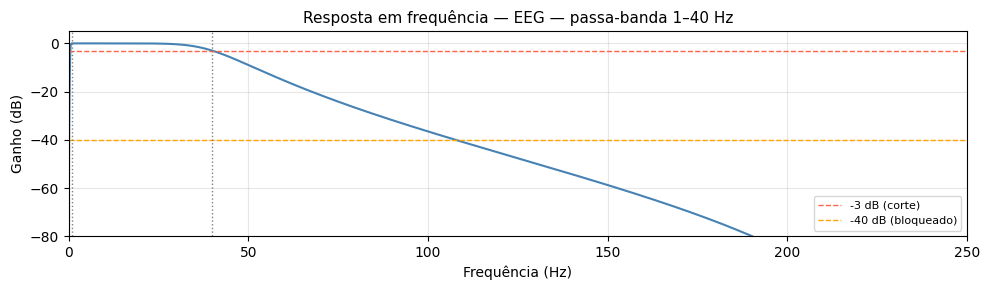

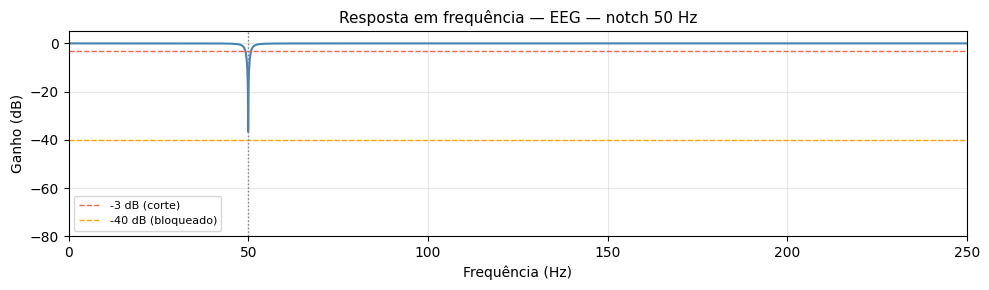

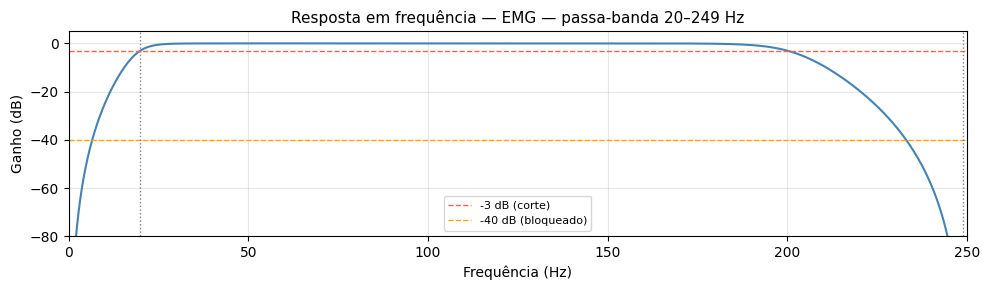

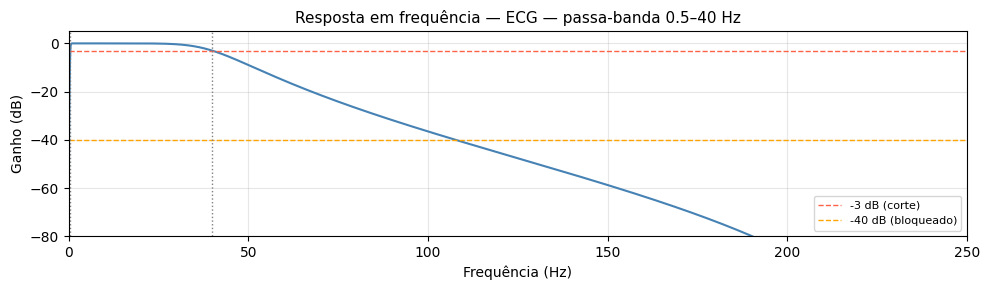

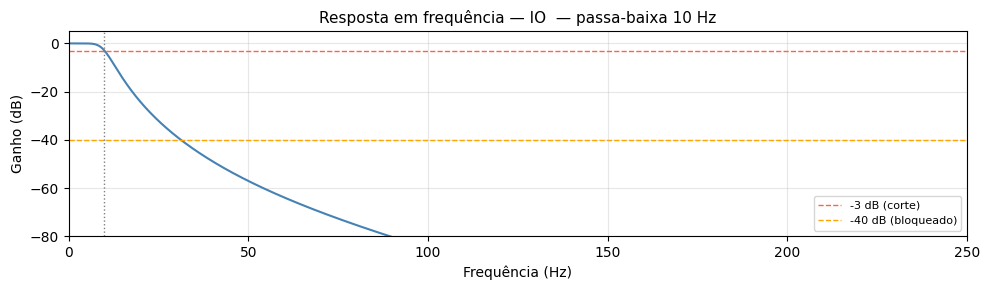

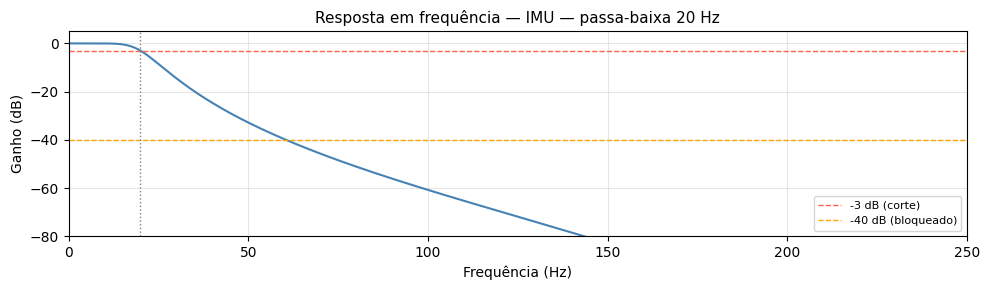

In [19]:
def plotar_filtro(sos_ou_ba, titulo: str, tipo: str = 'sos',
                  f_marcadores: list = None):
    """
    Plota a resposta em frequência de um filtro.
    f_marcadores: lista de frequências para marcar com linha vertical
    (ex: frequências de corte, frequência de notch)
    """
    if tipo == 'sos':
        w, h = sg.sosfreqz(sos_ou_ba, worN=4096, fs=FS)
    else:
        b, a = sos_ou_ba
        w, h = sg.freqz(b, a, worN=4096, fs=FS)

    ganho_db = 20 * np.log10(np.abs(h) + 1e-12)

    plt.figure(figsize=(10, 3))
    plt.plot(w, ganho_db, lw=1.5, color='steelblue')
    plt.axhline(-3,  color='tomato',    ls='--', lw=1, label='-3 dB (corte)')
    plt.axhline(-40, color='orange',    ls='--', lw=1, label='-40 dB (bloqueado)')
    if f_marcadores:
        for f in f_marcadores:
            plt.axvline(f, color='gray', ls=':', lw=1)
    plt.title(f"Resposta em frequência — {titulo}", fontsize=11)
    plt.xlabel("Frequência (Hz)")
    plt.ylabel("Ganho (dB)")
    plt.ylim(-80, 5)
    plt.xlim(0, NYQUIST)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plotar_filtro(sos_eeg,            "EEG — passa-banda 1–40 Hz",     f_marcadores=[1, 40])
plotar_filtro((b_notch, a_notch), "EEG — notch 50 Hz",   tipo='ba', f_marcadores=[FREQ_REDE_HZ])
plotar_filtro(sos_emg_unused,            "EMG — passa-banda 20–249 Hz",   f_marcadores=[20, 249])
plotar_filtro(sos_ecg,            "ECG — passa-banda 0.5–40 Hz",   f_marcadores=[0.5, 40])
plotar_filtro(sos_io,             "IO  — passa-baixa 10 Hz",        f_marcadores=[10])
plotar_filtro(sos_imu,            "IMU — passa-baixa 20 Hz",        f_marcadores=[20])

## Interpretação dos gráficos de resposta em frequência

Os gráficos mostram como cada filtro atua sobre diferentes frequências do sinal. Valores próximos de 0 dB indicam que a frequência passa praticamente sem alteração. Valores negativos indicam atenuação, isto é, redução da amplitude daquela frequência.

A linha tracejada vermelha em -3 dB representa a frequência de corte do filtro. Esse ponto é usado como referência padrão porque corresponde aproximadamente a uma redução da amplitude para 70,7% do valor original.

A linha tracejada laranja em -40 dB representa uma frequência já fortemente atenuada, praticamente removida do sinal.

### EEG — passa-banda 1–40 Hz

O filtro de EEG permanece próximo de 0 dB até aproximadamente 40 Hz. A partir desse ponto, a curva começa a cair, indicando que frequências acima de 40 Hz passam a ser removidas.

Esse intervalo foi escolhido porque a maior parte das bandas fisiológicas relevantes do EEG está abaixo de 40 Hz:

- Delta: 0.5–4 Hz
- Theta: 4–8 Hz
- Alpha: 8–13 Hz
- Beta: 13–30 Hz
- Parte da Gamma baixa: até cerca de 40 Hz

Frequências acima de 40 Hz costumam conter principalmente ruído muscular, interferência elétrica e artefatos.

### EEG — notch 50 Hz

O filtro notch apresenta uma queda muito estreita exatamente em 50 Hz. Isso ocorre porque ele foi projetado especificamente para remover a interferência da rede elétrica, já que os dados foram coletados na China, onde a rede opera em 50 Hz.

Diferentemente de um passa-baixa ou passa-banda, o notch remove apenas uma frequência muito específica sem afetar significativamente o restante do sinal.

### EMG — passa-banda 20–249 Hz

O gráfico do EMG começa com valores muito baixos em frequências próximas de 0 Hz. Em seguida, a curva cresce rapidamente, formando uma espécie de parábola com concavidade voltada para baixo, até atingir aproximadamente 20 Hz.

A partir de 20 Hz, a curva fica praticamente reta e próxima de 0 dB, indicando que essas frequências passam quase sem alteração. Isso continua até próximo de 249 Hz.

Perto de 250 Hz, que corresponde ao limite de Nyquist para sinais amostrados a 500 Hz, a curva cai rapidamente em direção a -80 dB.

Esse comportamento ocorre porque:

- abaixo de 20 Hz predominam artefatos de movimento, deriva de base e ruído de baixa frequência;
- entre 20 Hz e 249 Hz está a maior parte do conteúdo útil do EMG;
- acima de 250 Hz não é possível representar corretamente as frequências devido ao limite de Nyquist.

### ECG — passa-banda 0.5–40 Hz

O filtro de ECG permanece próximo de 0 dB até perto de 40 Hz e depois começa a cair gradualmente.

A frequência mínima de 0.5 Hz é utilizada para remover deriva de base e oscilações muito lentas causadas por movimento do corpo, suor e deslocamento dos eletrodos.

A frequência máxima de 40 Hz é utilizada porque a maior parte da informação relevante do ECG está abaixo desse valor. Acima disso, predominam ruídos musculares e interferências elétricas.

### IO — passa-baixa 10 Hz

No filtro do IO, a curva permanece próxima de 0 dB até aproximadamente 10 Hz. A partir desse ponto, ela começa a cair gradualmente.

Esse filtro passa-baixa foi utilizado porque o sinal IO representa um movimento fisiológico relativamente lento. Assim, frequências acima de 10 Hz tendem a corresponder principalmente a ruído e vibrações não relevantes.

### IMU — passa-baixa 20 Hz

No filtro da IMU, a curva permanece próxima de 0 dB até aproximadamente 20 Hz e depois começa a cair gradualmente.

Esse valor foi escolhido porque movimentos humanos típicos, como caminhar, mover braços e pernas ou mudar de postura, concentram a maior parte de sua energia abaixo de 20 Hz.

Frequências acima de 20 Hz costumam estar associadas a vibração do sensor, ruído eletrônico e pequenas oscilações sem relevância biomecânica.

## 3. Funções de Aplicação do Filtro

O desafio principal é lidar com **NaN no sinal**.
Filtros digitais não funcionam com NaN, uma única amostra NaN
se propaga e contamina todas as amostras seguintes com NaN também
(porque o filtro usa amostras passadas no cálculo de cada ponto).

A solução: preencher NaN temporariamente antes de filtrar,
e restaurar os NaN nas posições originais depois.

In [20]:
def aplicar_sos(sinal: np.ndarray, sos) -> np.ndarray:
    """
    Aplica um filtro SOS em um array de sinal, tratando NaN corretamente.

    Tratamento de NaN (em 3 passos):
    1. Registra onde estão os NaN
    2. Preenche NaN com interpolação linear (temporariamente)
       → o filtro agora tem um sinal contínuo para operar
    3. Aplica o filtro e restaura NaN nas posições originais
       → NaN de sensor ausente não some, não se propaga

    Usa sosfiltfilt = filtra em frente e em trás (fase zero).
    Isso evita que o filtro 'atrase' o sinal no tempo —
    importante para manter o alinhamento entre EEG e IMU.
    """
    nan_mask = np.isnan(sinal)

    # Canal 100% NaN: sensor ausente, nada a filtrar
    if nan_mask.all():
        return sinal

    # Preenche NaN temporariamente com interpolação linear
    # limit_direction='both' trata também as bordas (início e fim do sinal)
    sinal_continuo = (
        pd.Series(sinal)
        .interpolate(method='linear', limit_direction='both')
        .values
    )

    # Aplica o filtro no sinal contínuo (sem NaN)
    sinal_filtrado = sg.sosfiltfilt(sos, sinal_continuo)

    # Restaura NaN nas posições originais
    sinal_filtrado[nan_mask] = np.nan

    return sinal_filtrado.astype('float32')


def aplicar_ba(sinal: np.ndarray, b, a) -> np.ndarray:
    """
    Mesma lógica de aplicar_sos, mas para filtros no formato (b, a).
    Usado exclusivamente pelo filtro notch (que o scipy retorna em b,a).
    """
    nan_mask = np.isnan(sinal)
    if nan_mask.all():
        return sinal

    sinal_continuo = (
        pd.Series(sinal)
        .interpolate(method='linear', limit_direction='both')
        .values
    )
    sinal_filtrado = sg.filtfilt(b, a, sinal_continuo)
    sinal_filtrado[nan_mask] = np.nan

    return sinal_filtrado.astype('float32')


print("Funções de aplicação definidas.")

Funções de aplicação definidas.


## 4. Visualizar Antes × Depois num Canal de Cada Tipo

Antes de filtrar tudo, confirme visualmente o efeito num trecho pequeno.
Se o filtro estiver errado, descobrimos aqui e não depois de processar horas de dado de todos os pacientes.

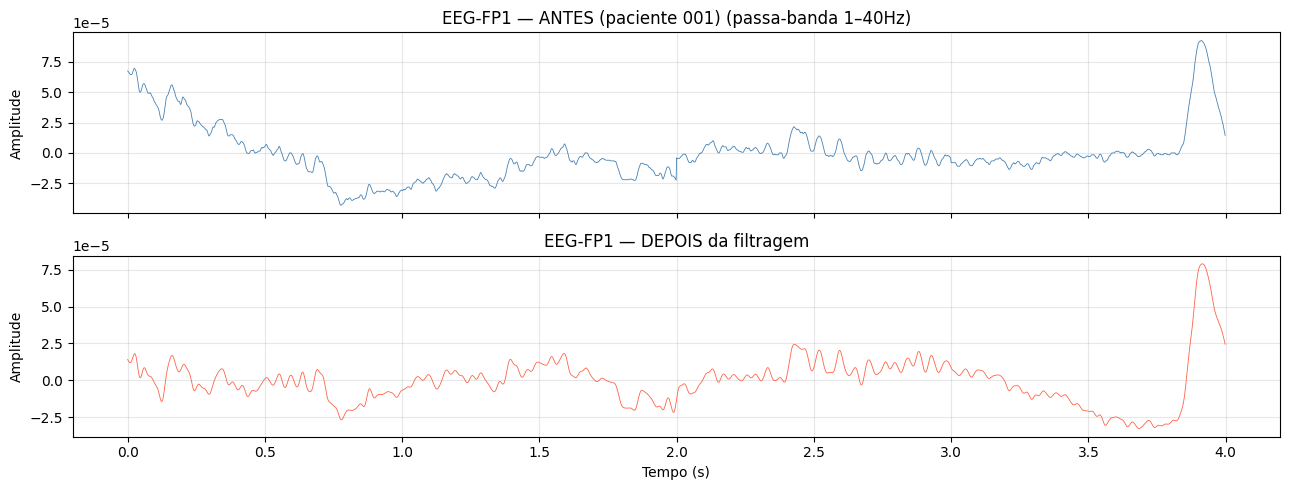

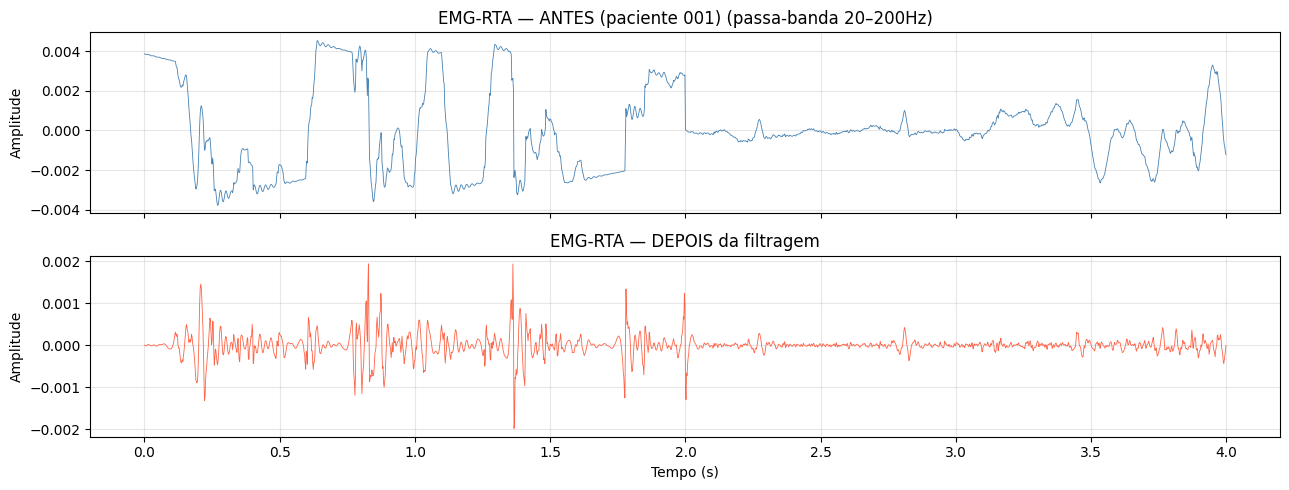

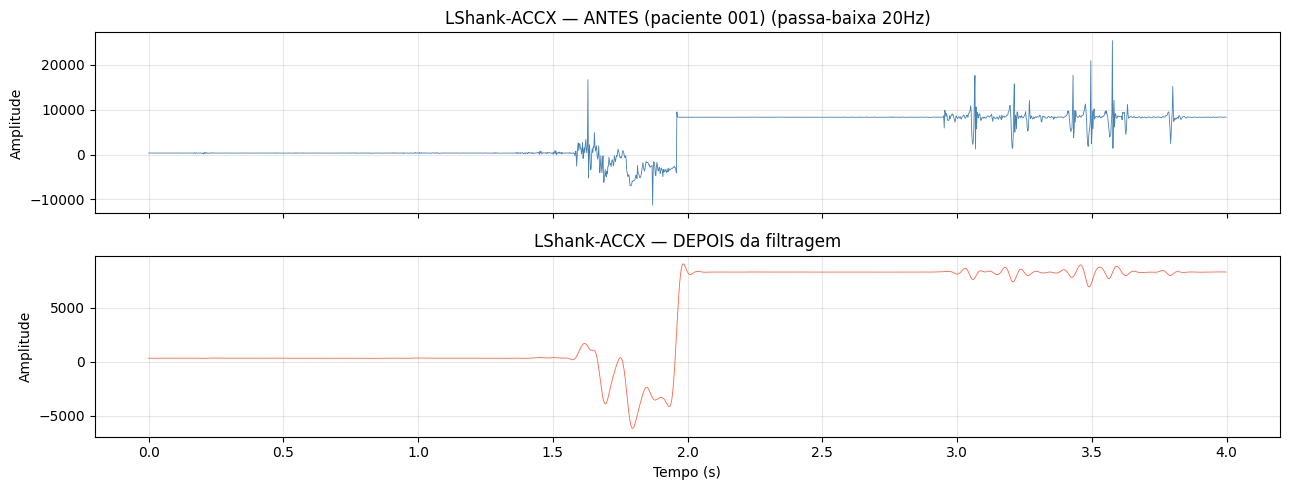

In [21]:
def plotar_antes_depois(df: pd.DataFrame, col: str,
                        sos, pid: str = None,
                        n: int = 2000, titulo_extra: str = ""):
    """
    Plota n amostras de um canal antes e depois da filtragem.
    n=2000 → 4 segundos a 500Hz.
    """
    pid = pid or df['patient_id'].iloc[0]
    valores = df[df['patient_id'] == pid][col].dropna().values[:n]

    if len(valores) < 50:
        print(f"  {col}: dados insuficientes para plotar")
        return

    filtrado = sg.sosfiltfilt(sos, valores)
    tempo    = np.arange(len(valores)) / FS

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
    ax1.plot(tempo, valores,  lw=0.6, color='steelblue')
    ax1.set_title(f"{col} — ANTES (paciente {pid}) {titulo_extra}")
    ax1.set_ylabel("Amplitude"); ax1.grid(alpha=0.3)

    ax2.plot(tempo, filtrado, lw=0.6, color='tomato')
    ax2.set_title(f"{col} — DEPOIS da filtragem")
    ax2.set_ylabel("Amplitude"); ax2.set_xlabel("Tempo (s)")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


pid_ex = sorted(df['patient_id'].unique())[0]

# EEG — efeito do passa-banda 1–40Hz
col_eeg = next((c for c in EEG_COLS if c in df.columns
                and df[df['patient_id']==pid_ex][c].notna().any()), None)
if col_eeg:
    plotar_antes_depois(df, col_eeg, sos_eeg, pid_ex,
                        titulo_extra="(passa-banda 1–40Hz)")

# EMG — efeito do passa-banda 20–200Hz
col_emg = next((c for c in EMG_COLS if c in df.columns
                and df[df['patient_id']==pid_ex][c].notna().any()), None)
if col_emg:
    plotar_antes_depois(df, col_emg, sos_emg_unused, pid_ex,
                        titulo_extra="(passa-banda 20–200Hz)")

# IMU — efeito do passa-baixa 20Hz
col_imu = next((c for c in IMU_COLS_SINAL if c in df.columns
                and df[df['patient_id']==pid_ex][c].notna().any()), None)
if col_imu:
    plotar_antes_depois(df, col_imu, sos_imu, pid_ex,
                        titulo_extra="(passa-baixa 20Hz)")

## Interpretação dos sinais antes e depois da filtragem

### EEG

No sinal de EEG, é comum observar antes da filtragem uma tendência lenta de subida ou descida ao longo do tempo. Esse comportamento geralmente está associado à deriva de base, movimentação do eletrodo, suor ou componentes muito lentas do sinal. Vemos isso no aspecto de sinal "caindo" no começo antes de ser filtrado.

Após aplicar o filtro passa-banda de 1–40 Hz, essas componentes lentas são removidas e o sinal tende a ficar mais centralizado em torno do eixo horizontal, comos e tivéssemos puxado ele pro eixo x.

Também é comum que picos bruscos do sinal mudem ligeiramente de formato após a filtragem como uma descida aparecendo antes da subida final que vemos no depois da filtragem.

Essa pequena vala antes do pico é um comportamento esperado do filtro e ocorre porque a filtragem passa-banda remove componentes lentas e tenta preservar apenas as variações rápidas do sinal.

Como foi utilizado `sosfiltfilt`, o filtro é aplicado para frente e para trás no tempo. Isso melhora a preservação de fase, mas pode introduzir pequenas oscilações próximas de transições bruscas, como picos muito intensos.

Esse efeito é conhecido como ringing, overshoot ou undershoot e costuma ocorrer:

- próximo de picos abruptos;
- em mudanças rápidas do sinal;
- quando componentes lentas são removidas;
- quando se utiliza filtragem bidirecional.

Se essa pequena vala aparece apenas perto de picos e não domina o sinal inteiro, ela é considerada normal.

### EMG

No EMG, antes da filtragem, é comum que o sinal apresente tendências lentas e grandes oscilações largas, formando algo parecido com “montanhas cortadas no topo” ou blocos largos.

Após a filtragem passa-banda de 20–249 Hz, essas componentes lentas são removidas. Como consequência, o sinal passa a destacar apenas as variações rápidas associadas à atividade muscular.

Por isso, depois da filtragem, o EMG tende a ficar mais “nervoso”, com muitos picos e vales rápidos. Isso não significa perda de informação; pelo contrário, significa que a atividade muscular de interesse foi destacada e que as componentes lentas e artificiais foram removidas.

### IMU

Nos sinais de IMU, o objetivo é remover vibrações rápidas e ruído de alta frequência.

Após a aplicação do filtro passa-baixa de 20 Hz, o formato geral do movimento é preservado, mas o sinal fica mais suave e contínuo.

Assim, movimentos reais do corpo continuam visíveis, enquanto pequenas oscilações rápidas, vibrações do sensor e ruído eletrônico são reduzidos.

## 5. Aplicar Filtragem em Todos os Pacientes × Sessões

Para cada bloco (paciente + sessão), aplicamos os filtros
na sequência correta:
1. EEG: passa-banda → notch
2. EMG: passa-banda
3. ECG: passa-banda
4. IO: passa-baixa
5. IMU (ACC + GYRO): passa-baixa

A ordem importa no EEG: passa-banda primeiro remove a deriva DC
e os artefatos musculares grosseiros, depois o notch cirúrgico
age sobre um sinal já mais limpo: resultado mais preciso.

In [22]:
def filtrar_bloco(df_bloco: pd.DataFrame) -> pd.DataFrame:
    """
    Aplica todos os filtros em um bloco (paciente + sessão).

    Somente colunas de sinal são tocadas.
    Metadados (timestamp, patient_id, task_id, session) e label
    são preservados intactos.
    """
    df_out = df_bloco.copy()

    # ── EEG ──────────────────────────────────────────────────────────────────
    # Ordem: passa-banda PRIMEIRO, notch DEPOIS
    # Motivo: o passa-banda já remove grande parte do ruído, deixando o
    # notch agir sobre um sinal mais limpo — resultado mais preciso
    eeg_presentes = [c for c in EEG_COLS if c in df_out.columns]
    for col in eeg_presentes:
        sinal = df_out[col].values.astype(float)
        sinal = aplicar_sos(sinal, sos_eeg)          # 1–40Hz
        sinal = aplicar_ba(sinal, b_notch, a_notch)  # remove 50Hz
        df_out[col] = sinal

    # ── EMG ──────────────────────────────────────────────────────────────────
    emg_presentes = [c for c in EMG_COLS if c in df_out.columns]
    for col in emg_presentes:
        sinal = df_out[col].values.astype(float)
        sinal = aplicar_ba(sinal, b_notch, a_notch)   # apenas remove 50Hz (rede elétrica)
        df_out[col] = sinal
        # Sem passa-banda: referência tem pico em 1–3Hz (componente de movimento preservada)

    # ── ECG ──────────────────────────────────────────────────────────────────
    if 'ECG' in df_out.columns:
        sinal = df_out['ECG'].values.astype(float)
        df_out['ECG'] = aplicar_sos(sinal, sos_ecg)  # 0.5–40Hz

    # ── IO (eletrodo ocular) ──────────────────────────────────────────────────
    if 'IO' in df_out.columns:
        sinal = df_out['IO'].values.astype(float)
        df_out['IO'] = aplicar_sos(sinal, sos_io)    # 0–10Hz

    # ── IMU: ACC e GYRO ───────────────────────────────────────────────────────
    # NC/SC não é sinal de movimento — não filtramos
    imu_presentes = [c for c in IMU_COLS_SINAL if c in df_out.columns]
    for col in imu_presentes:
        sinal = df_out[col].values.astype(float)
        df_out[col] = aplicar_sos(sinal, sos_imu)    # 0–20Hz

    return df_out


print("Iniciando filtragem por paciente × sessão...")
print("-" * 55)

blocos_filtrados = []

for (pid, sessao), df_bloco in df.groupby(['patient_id', 'session'], sort=True):
    n = len(df_bloco)
    df_f = filtrar_bloco(df_bloco)
    blocos_filtrados.append(df_f)
    print(f"  {pid} / sessão {sessao}: {n:>8,} amostras filtradas")

df_filtrado = pd.concat(blocos_filtrados, ignore_index=True)

print(f"\nShape final: {df_filtrado.shape[0]:,} × {df_filtrado.shape[1]}")

Iniciando filtragem por paciente × sessão...
-------------------------------------------------------
  001 / sessão 1:  110,582 amostras filtradas
  002 / sessão 1:  235,098 amostras filtradas
  003 / sessão 1:  261,385 amostras filtradas
  004 / sessão 1:  112,327 amostras filtradas
  005 / sessão 1:   92,351 amostras filtradas
  006 / sessão 1:  108,065 amostras filtradas
  007 / sessão 1:  163,304 amostras filtradas
  008 / sessão 1:   98,910 amostras filtradas
  008 / sessão 2:   85,110 amostras filtradas
  009 / sessão 1:  135,806 amostras filtradas
  010 / sessão 1:  215,520 amostras filtradas
  011 / sessão 1:  166,308 amostras filtradas
  012 / sessão 1:  151,704 amostras filtradas

Shape final: 1,936,470 × 63


## 6. Verificação Pós-Filtragem

Três coisas que não podem ter mudado durante a filtragem:
1. Número de linhas (filtragem não remove amostras)
2. Posições de NaN (filtragem não cria nem remove NaN)
3. Metadados e label (não foram tocados)

In [23]:
# ── Integridade estrutural ────────────────────────────────────────────────────
assert len(df_filtrado) == len(df), \
    f"❌ Linhas mudaram: {len(df):,} → {len(df_filtrado):,}"
print(f"Linhas: {len(df_filtrado):,}  ✅ (igual ao input)")

# Verifica que os NaNs do EEG não mudaram
# (NaN de EEG seria incomum e indicaria corrupção na Parte 2)
eeg_pres = [c for c in EEG_COLS if c in df.columns]
nans_eeg_antes  = df[eeg_pres].isna().sum().sum()
nans_eeg_depois = df_filtrado[eeg_pres].isna().sum().sum()
assert nans_eeg_antes == nans_eeg_depois, \
    f"❌ NaNs no EEG mudaram: {nans_eeg_antes} → {nans_eeg_depois}"
print(f"NaNs EEG: {nans_eeg_antes}  ✅ (inalterado)")

# Label e patient_id intactos
assert df['patient_id'].reset_index(drop=True).equals(
    df_filtrado['patient_id'].reset_index(drop=True)), \
    "❌ patient_id foi alterado!"
print("patient_id: ✅ intacto")

print("\nTodos os testes de integridade passaram. ✅")

Linhas: 1,936,470  ✅ (igual ao input)
NaNs EEG: 5809410  ✅ (inalterado)
patient_id: ✅ intacto

Todos os testes de integridade passaram. ✅


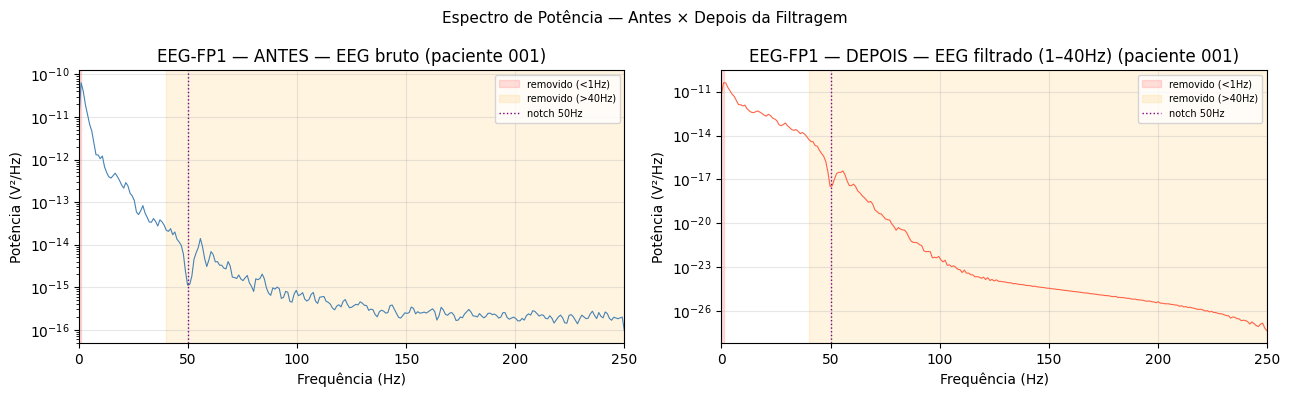

No gráfico DEPOIS: a potência nas regiões em vermelho/laranja
deve ser muito menor do que no gráfico ANTES.


In [24]:
# ── Comparação espectral antes × depois ───────────────────────────────────────
# O espectro de potência mostra quais frequências existem no sinal.
# Após filtrar o EEG com passa-banda 1–40Hz:
#   - frequências 0–1Hz devem sumir (deriva DC removida)
#   - frequências 40–250Hz devem sumir (ruído muscular removido)
#   - frequências 1–40Hz devem permanecer

if col_eeg and col_eeg in df_filtrado.columns:
    pid_ex   = sorted(df['patient_id'].unique())[0]
    bruto    = df[df['patient_id']==pid_ex][col_eeg].dropna().values[:5000].astype(float)
    filtrado = df_filtrado[df_filtrado['patient_id']==pid_ex][col_eeg].dropna().values[:5000].astype(float)

    # Densidade espectral de potência (PSD) via Welch
    # Welch faz uma média de espectros de segmentos sobrepostos
    # — resultado mais estável do que a FFT simples
    f_b, psd_b = sg.welch(bruto,    fs=FS, nperseg=512)
    f_f, psd_f = sg.welch(filtrado, fs=FS, nperseg=512)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ax, (f, psd, cor, titulo) in zip(axes, [
        (f_b, psd_b, 'steelblue', 'ANTES — EEG bruto'),
        (f_f, psd_f, 'tomato',    'DEPOIS — EEG filtrado (1–40Hz)'),
    ]):
        ax.semilogy(f, psd, lw=0.8, color=cor)
        ax.axvspan(0,   1,  alpha=0.12, color='red',    label='removido (<1Hz)')
        ax.axvspan(40, 250, alpha=0.12, color='orange', label='removido (>40Hz)')
        ax.axvline(FREQ_REDE_HZ, color='purple', ls=':', lw=1,
                   label=f'notch {FREQ_REDE_HZ:.0f}Hz')
        ax.set_title(f"{col_eeg} — {titulo} (paciente {pid_ex})")
        ax.set_xlabel("Frequência (Hz)")
        ax.set_ylabel("Potência (V²/Hz)")
        ax.set_xlim(0, NYQUIST)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    plt.suptitle("Espectro de Potência — Antes × Depois da Filtragem", fontsize=11)
    plt.tight_layout()
    plt.show()
    print("No gráfico DEPOIS: a potência nas regiões em vermelho/laranja")
    print("deve ser muito menor do que no gráfico ANTES.")

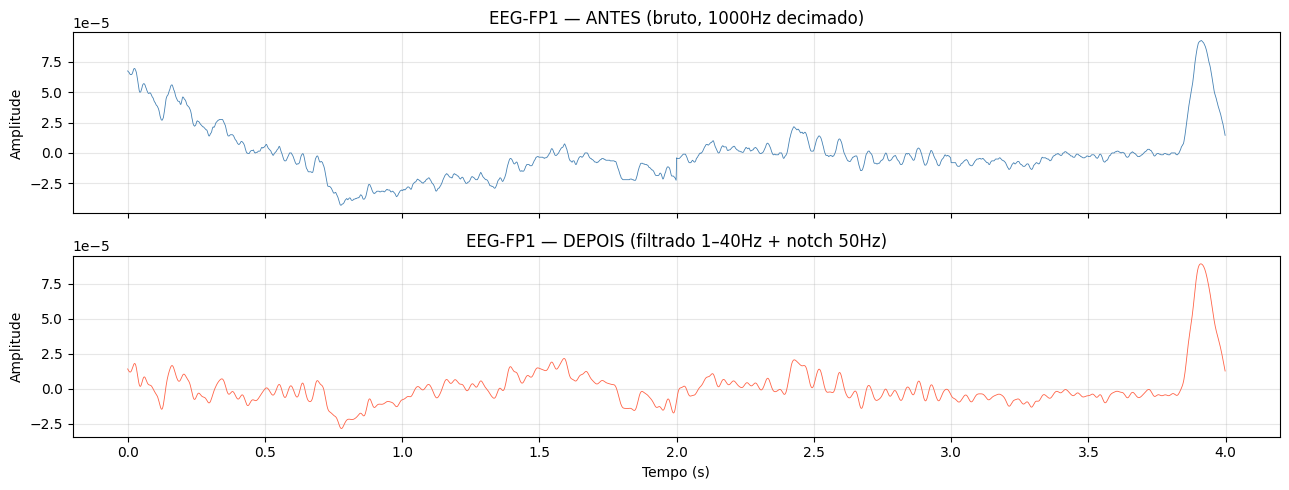

In [25]:
# ── Comparação no tempo: 4 segundos de EEG antes × depois ────────────────────
if col_eeg:
    N    = 2000   # 4 segundos a 500Hz
    t    = np.arange(N) / FS
    pid_ex = sorted(df['patient_id'].unique())[0]

    v_antes  = df[df['patient_id']==pid_ex][col_eeg].dropna().values[:N].astype(float)
    v_depois = df_filtrado[df_filtrado['patient_id']==pid_ex][col_eeg].dropna().values[:N].astype(float)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
    ax1.plot(t, v_antes,  lw=0.6, color='steelblue')
    ax1.set_title(f"{col_eeg} — ANTES (bruto, 1000Hz decimado)")
    ax1.set_ylabel("Amplitude"); ax1.grid(alpha=0.3)

    ax2.plot(t, v_depois, lw=0.6, color='tomato')
    ax2.set_title(f"{col_eeg} — DEPOIS (filtrado 1–40Hz + notch {FREQ_REDE_HZ:.0f}Hz)")
    ax2.set_ylabel("Amplitude"); ax2.set_xlabel("Tempo (s)")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 7. Salvar

In [26]:
# Garante float32 em todos os canais de sinal antes de salvar
# (economiza ~50% de memória vs float64 com perda de precisão desprezível)
all_signal_cols = EEG_COLS + BIO_COLS + IMU_COLS_SINAL
for col in [c for c in all_signal_cols if c in df_filtrado.columns]:
    df_filtrado[col] = df_filtrado[col].astype('float32')

df_filtrado.to_parquet(FILTERED_PATH, index=False)

print(f"Salvo: {FILTERED_PATH}")
print(f"  Linhas:   {len(df_filtrado):,}")
print(f"  Colunas:  {df_filtrado.shape[1]}")
print(f"  Memória:  {df_filtrado.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"  Pacientes: {sorted(df_filtrado['patient_id'].unique())}")
print("\n Parte 3 concluída.")
print("   Sinais filtrados e limpos de ruído.")
print("   Prossiga para a Parte 4: Normalização e Comparação com Referência.")

Salvo: ../data/silver/filtered.parquet
  Linhas:   1,936,470
  Colunas:  63
  Memória:  548.0 MB
  Pacientes: ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012']

 Parte 3 concluída.
   Sinais filtrados e limpos de ruído.
   Prossiga para a Parte 4: Normalização e Comparação com Referência.
